# Experiment 1 - Cost of Basic Operations

Times encryption, addition, multiplication, summation, average, dot product and decryption in plaintext, TenSEAL and OpenFHE, and reports each encrypted operation as a multiple of its plaintext equivalent.

Also times key generation, and measures memory, ciphertext size and approximation error.

Corresponds to Experiment 1 in the report, *Results: The Cost of Basic Operations*.

## 1. Install and load the project


In [1]:
import subprocess
import sys

# TenSEAL publishes real platform-tagged wheels (win_amd64 / manylinux / macosx,
# CPython 3.8-3.12), so it installs anywhere. Pinned to the version the report used.
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "tenseal==0.3.15", "numpy", "matplotlib"], check=True)

# OpenFHE is the opposite. Every OpenFHE distribution on PyPI is tagged
# `py3-none-any`, but the payload is Linux ELF binaries built against one
# specific CPython. The 1.4.1 line, which the report used, is:
#
#     openfhe==1.4.1.0.20.4   Ubuntu 20.04   cpython-38    requires_python >=3.8
#     openfhe==1.4.1.0.22.4   Ubuntu 22.04   cpython-310   requires_python >=3.10
#     openfhe==1.4.1.0.24.4   Ubuntu 24.04   cpython-312   requires_python >=3.12
#
# Those bounds are `>=`, so an unpinned install takes the newest wheel whose
# bound this interpreter satisfies -- which need not be built for it. On 3.10
# and 3.12 that happens to land on a valid build; on 3.9, 3.11 and 3.13 it does
# not (3.11 resolves to the cpython-310 wheel openfhe==1.5.1.0.22.4), installs
# with no warning, and fails at *import*. Pinning also keeps the OpenFHE version
# identical to the report's.
OPENFHE_WHEELS = {(3, 8): "1.4.1.0.20.4", (3, 10): "1.4.1.0.22.4", (3, 12): "1.4.1.0.24.4"}
_py = sys.version_info[:2]
_wheel = OPENFHE_WHEELS.get(_py)

if sys.platform != "linux":
    print(f"Skipping OpenFHE: no wheel has ever been published for {sys.platform!r}. "
          "The plaintext and TenSEAL columns still run.")
elif _wheel is None:
    _have = ", ".join(f"{a}.{b}" for a, b in sorted(OPENFHE_WHEELS))
    print(f"Skipping OpenFHE: no build exists for CPython {_py[0]}.{_py[1]} "
          f"(builds exist for {_have}). The plaintext and TenSEAL columns still run.")
else:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    f"openfhe=={_wheel}"], check=True)
    print(f"Installed openfhe=={_wheel} for CPython {_py[0]}.{_py[1]}.")

Installed openfhe==1.4.1.0.24.4 for CPython 3.12.


In [2]:
import os
import subprocess
import sys

REPO = "https://github.com/To2004/confidential-computing-project.git"

# Works both on a fresh Colab runtime and inside a local checkout.
if not os.path.exists("src/benchmark_harness.py"):
    if not os.path.exists("confidential-computing-project"):
        subprocess.run(["git", "clone", "-q", REPO], check=True)
    os.chdir("confidential-computing-project")

# Absolute, so imports survive a later change of directory, and guarded so
# re-running this cell does not stack duplicate entries.
SRC = os.path.abspath("src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

# Write this notebook's output to its own directory, so running it does not
# overwrite the results and figures the report was built from.
import benchmark_harness as harness
import project_paths

os.makedirs("notebook_output", exist_ok=True)
project_paths.RESULTS_DIR = "notebook_output"
project_paths.FIGURES_DIR = "notebook_output"

print("working directory:", os.getcwd())
print("report uses", harness.DEFAULT_REPEATS, "repetitions per measurement")

working directory: /mnt/c/Users/user/Desktop/coursework/confidential-computing-project
report uses 1000 repetitions per measurement


## 2. Check which libraries loaded

OpenFHE only publishes Linux binaries, and each build targets one specific
CPython (3.8, 3.10 or 3.12). On any other platform or Python version the
install cell above skips it, so it will not be listed as available here.

Without OpenFHE the experiment still runs, with the plaintext and TenSEAL columns only.

In [3]:
import importlib

for name in ("tenseal", "openfhe"):
    try:
        importlib.import_module(name)
        print(f"{name}: available")
    except Exception as exc:
        print(f"{name}: not available -- {exc}")

tenseal: available
openfhe: available


## 3. The measurement instrument

Every number in this experiment - plaintext, TenSEAL and OpenFHE alike - comes out of one
shared module, `src/benchmark_harness.py`. The three columns of every table below differ
*only* in the call being timed: same clock, same warm-up policy, same statistics, same drift
check.

The cells in this section display the real source, read out of `src/` at run time, so a
snippet shown here cannot drift from the code that produced the numbers.

In [4]:
import notebook_tools as nt

nt.show_source(
    "benchmark_harness.py", "time_operation",
    note="Four decisions in twelve lines: warm-up calls are discarded; GC is disabled inside "
         "the measured loop, as CPython's own `timeit` does, so an unrelated collection is "
         "never charged to the operation under test; `perf_counter` wraps a *single* call "
         "rather than a batch; and GC is restored in a `finally`, so the process is never "
         "left with collection switched off.")

**`src/benchmark_harness.py` — `time_operation`**  
Four decisions in twelve lines: warm-up calls are discarded; GC is disabled inside the measured loop, as CPython's own `timeit` does, so an unrelated collection is never charged to the operation under test; `perf_counter` wraps a *single* call rather than a batch; and GC is restored in a `finally`, so the process is never left with collection switched off.

```python
def time_operation(fn, repeats=DEFAULT_REPEATS, warmup=DEFAULT_WARMUP,
                   keep_samples=True):
    """Time `fn` over `repeats` calls after `warmup` discarded calls.

    GC is disabled during the measured loop (as `timeit` does) so a collection
    triggered by unrelated allocations is not charged to the operation.
    """
    if repeats < 1:
        raise ValueError(f"repeats must be >= 1, got {repeats}")
    if warmup < 0:
        raise ValueError(f"warmup must be >= 0, got {warmup}")

    for _ in range(warmup):
        fn()

    samples_s = []
    gc_was_enabled = gc.isenabled()
    gc.disable()
    try:
        for _ in range(repeats):
            start = time.perf_counter()
            fn()
            samples_s.append(time.perf_counter() - start)
    finally:
        if gc_was_enabled:
            gc.enable()

    stats = summarize(samples_s, warmup=warmup)
    # Needs samples in acquisition order, which summarize() sorts away.
    stats.update(_drift_diagnostics(samples_s))

    # Prefer the dependence-aware interval; ci95_method records the fallback.
    batched = _batch_means_half_width_ms(samples_s)
    if batched is None:
        stats["ci95_half_width_ms"] = stats["ci95_iid_half_width_ms"]
        stats["ci95_method"] = "iid (too few samples to batch)"
    else:
        stats["ci95_half_width_ms"] = batched
        stats["ci95_method"] = "batch means (25 batches)"
        iid = stats["ci95_iid_half_width_ms"]
        stats["ci95_inflation_vs_iid"] = (batched / iid) if iid > 0 else None
    if keep_samples:
        stats["samples_ms"] = [round(s * 1000.0, 6) for s in samples_s]
    return stats
```

In [5]:
nt.show_source(
    "benchmark_harness.py", "assert_accuracy",
    note="Correctness gates the timing. Every decrypted result is compared against the "
         "plaintext computation of the same values, and a misconfigured run raises here "
         "rather than reporting fast, wrong numbers.")

**`src/benchmark_harness.py` — `assert_accuracy`**  
Correctness gates the timing. Every decrypted result is compared against the plaintext computation of the same values, and a misconfigured run raises here rather than reporting fast, wrong numbers.

```python
def assert_accuracy(results, thresholds, label=""):
    """Fail if any measured error exceeds its threshold.

    Thresholds are set orders of magnitude above the observed errors, so this
    catches broken crypto parameters, not ordinary CKKS noise.
    """
    failures = []
    for key, limit in thresholds.items():
        measured = results.get(key)
        if measured is None:
            failures.append(f"{key} was never measured")
        elif not measured <= limit:
            failures.append(f"{key} = {measured:.3e} exceeds limit {limit:.3e}")
    if failures:
        where = f" [{label}]" if label else ""
        raise AccuracyError(
            f"decrypted results are not accurate enough{where}: "
            + "; ".join(failures)
            + ". This usually means the crypto parameters cannot support the "
              "circuit (too few levels, or scale out of bounds)."
        )
```

### One harness, three backends

Each backend hands the harness a dict of zero-argument closures, and the harness never learns
which library it is timing. Every closure rebuilds its result from the same fresh operands, so
no repetition inherits accumulated noise or a consumed multiplicative level from the one before
it - call 1000 does identical work to call 1.

In [6]:
for filename in ("plaintext_baseline.py", "tenseal_benchmark.py", "openfhe_benchmark.py"):
    nt.show_assignment(filename, "run_benchmark", "operations")

**`src/plaintext_baseline.py` — `operations` in `run_benchmark`**

```python
    operations = {
        "add": lambda: [v + v for v in vector],
        "mul": lambda: [v * v for v in vector],
        "sum": lambda: sum(vector),
        "avg": lambda: sum(vector) / n,
        "dot": lambda: sum(a * b for a, b in zip(vector, vector2)),
    }
```

**`src/tenseal_benchmark.py` — `operations` in `run_benchmark`**

```python
    operations = {
        "encrypt": lambda: ts.ckks_vector(ctx, vector),
        "add": lambda: enc + enc,
        "mul": lambda: enc * enc,
        "sum": lambda: enc.sum(),
        "avg": lambda: enc.sum() * (1.0 / n),
        "dot": lambda: (enc * enc2).sum(),
        "decrypt": lambda: enc.decrypt(),
    }
```

**`src/openfhe_benchmark.py` — `operations` in `run_benchmark`**

```python
    operations = {
        "encrypt": lambda: cc.Encrypt(keys.publicKey, cc.MakeCKKSPackedPlaintext(vector)),
        "add": lambda: cc.EvalAdd(ct, ct),
        "mul": lambda: cc.EvalMult(ct, ct),
        "sum": lambda: cc.EvalSum(ct, n),
        "avg": lambda: cc.EvalMult(cc.EvalSum(ct, n), 1.0 / n),
        "dot": lambda: cc.EvalInnerProduct(ct, ct2, n),
        "decrypt": lambda: cc.Decrypt(keys.secretKey, ct),
    }
```

## 4. Run the experiment

`REPEATS` is the number of timed repetitions per measurement. The report uses 1000 on a reserved compute node; this notebook uses fewer so it finishes in a few minutes. The numbers it prints will therefore be noisier than the ones in the report.

In [7]:
# 200 rather than a smaller number for one specific reason: the batch-means
# confidence interval needs at least 25 x 4 = 100 samples, and below that the
# harness falls back to the naive i.i.d. formula. Section 6 compares the two.
REPEATS = 200

!"{sys.executable}" src/run_comparison.py --repeats {REPEATS} --warmup 10 --keygen-repeats 5 --output notebook_output/results.json

Input vector : [1.0, 2.0, 3.0, 4.0, 5.0]
Vector length: 5
Timing       : 200 repetitions per operation, 10 discarded warm-up calls

Running plaintext baseline...
  [Plaintext] add          timing 200 reps (+10 warm-up)...

 mean    0.0002 ms ± 0.0000 (median 0.0001, 81.1% rel. sd)  <-- DRIFT
  [Plaintext] mul          timing 200 reps (+10 warm-up)...

 mean    0.0002 ms ± 0.0000 (median 0.0001, 10.5% rel. sd)  <-- DRIFT
  [Plaintext] sum          timing 200 reps (+10 warm-up)...

 mean    0.0001 ms ± 0.0000 (median 0.0001, 17.9% rel. sd)  <-- DRIFT
  [Plaintext] avg          timing 200 reps (+10 warm-up)...

 mean    0.0002 ms ± 0.0000 (median 0.0001, 28.3% rel. sd)  <-- DRIFT
  [Plaintext] dot          timing 200 reps (+10 warm-up)...

...

 mean  113.6060 ms ± 6.0538 (median 107.8900, 31.1% rel. sd)  <-- DRIFT
  [OpenFHE] decrypt      timing 200 reps (+10 warm-up)...

 mean    9.4742 ms ± 1.8480 (median 7.3290, 86.2% rel. sd)  <-- DRIFT
  [!] first/second-half means differ by more than 5.0% for: encrypt, add, sum, avg, dot, decrypt
      Treat those means as contaminated by machine load, not as steady-state cost.


Timing key generation (5 repetitions)...



                                Mean Time per Operation (ms)                                
Operation          Plaintext       TenSEAL         OpenFHE     TS overhead    FHE overhead
--------------------------------------------------------------------------------------------
Encrypt                    —        2.8020          7.2552               —               —
Add                 0.000169        0.0763          0.1947            452x          1,152x
Multiply            0.000152        1.9465         28.5990         12,788x        187,880x
Sum                 0.000113        4.4471         98.5710         39,225x        869,424x
Average             0.000153        5.0583         87.4226         33,042x        571,072x
Dot Product         0.000376        4.8105        113.6060         12,791x        302,087x
Decrypt                    —        0.6709          9.4742               —               —
-------------------------------------------------------------------------------------


Results saved to notebook_output/results.json


## 5. Results


Saved notebook_output/chart_operations.png


Saved notebook_output/chart_errors.png


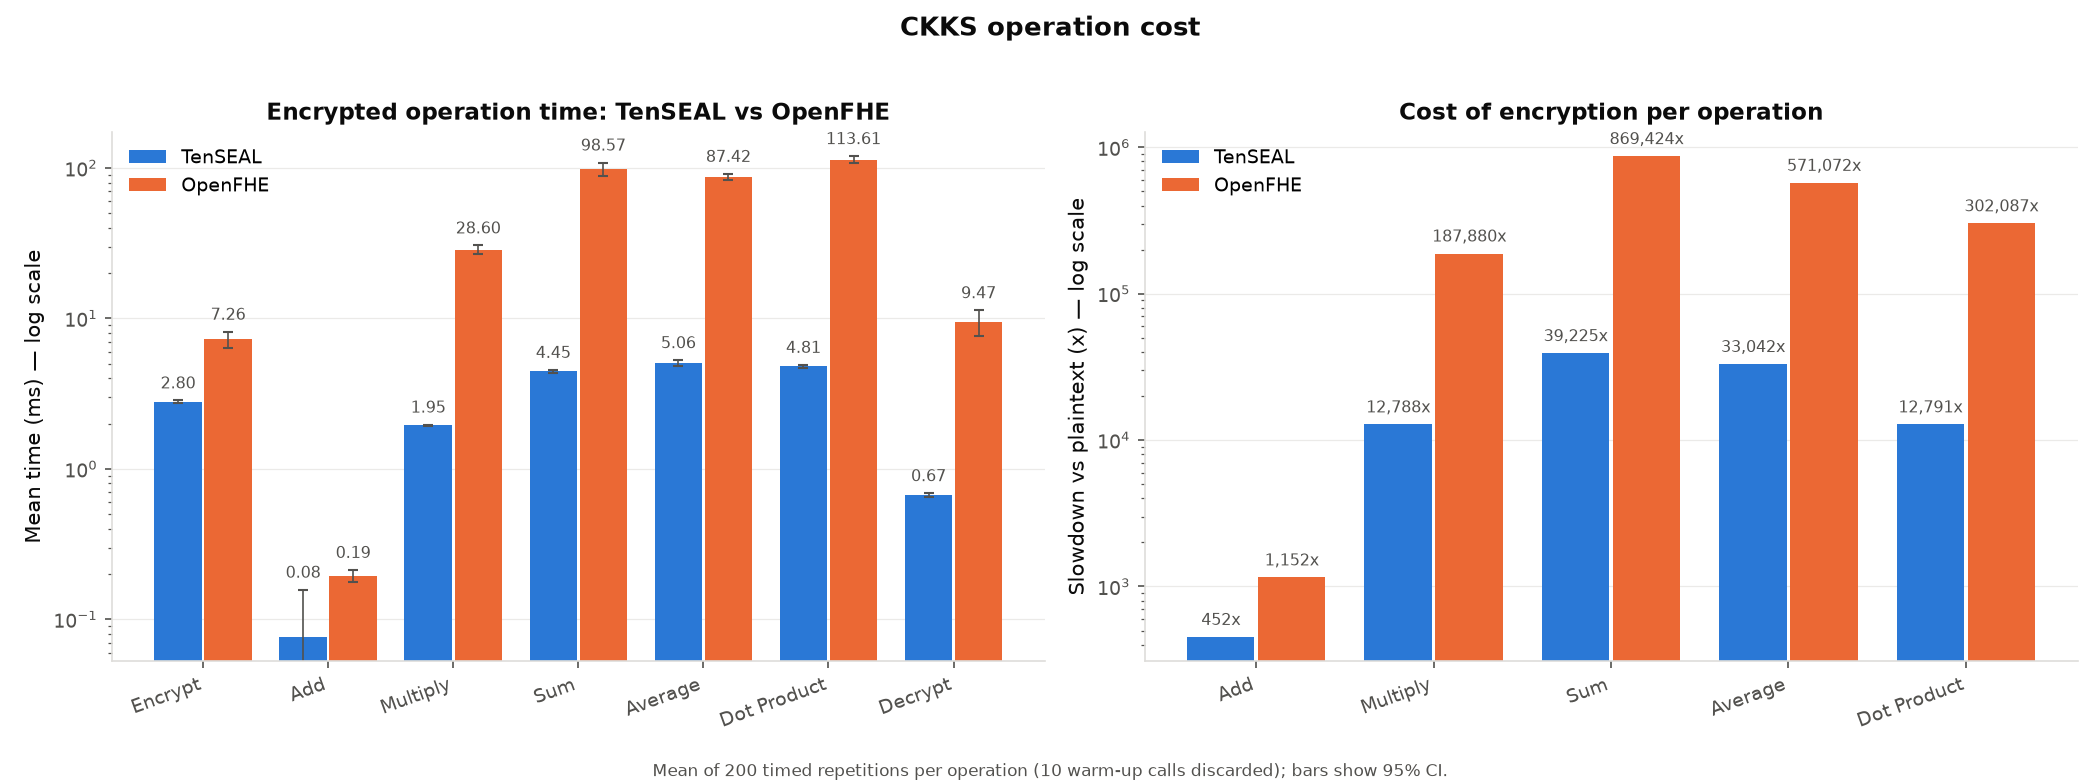

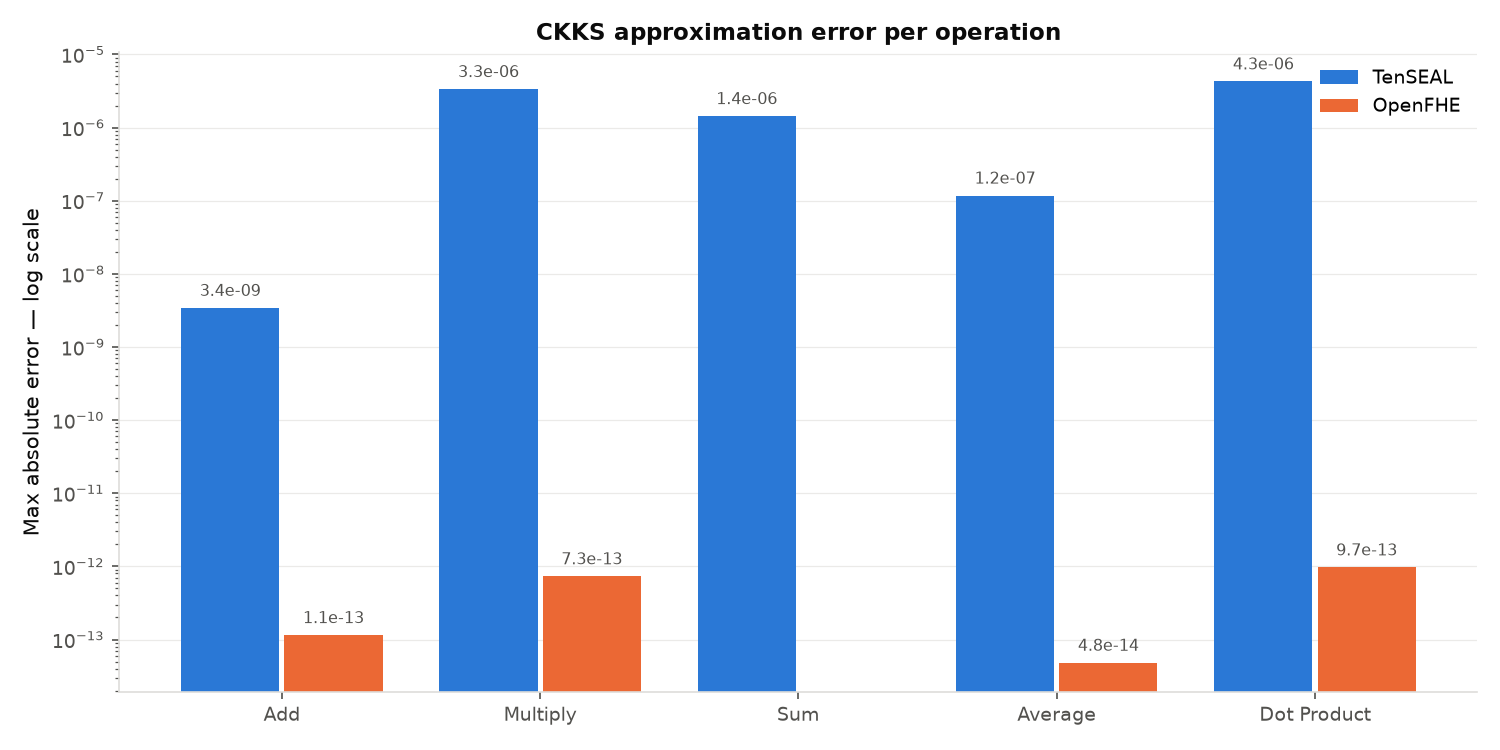

In [8]:
import plot_results as pr
from IPython.display import Image, display

data = pr.load("results.json")
pr.apply_style()
pr.chart_operations(data)
pr.chart_errors(data)

display(Image("notebook_output/chart_operations.png"))
display(Image("notebook_output/chart_errors.png"))

## 6. Are these numbers trustworthy?

A confidence interval measures how consistent the samples are *with each other*, assuming they
are independent draws from one distribution. Back-to-back timings are **not** independent -
they share cache, CPU frequency and scheduler state - and if the machine changes underneath the
benchmark, the interval does not notice. It gets narrower, not wider.

The harness therefore does two things beyond reporting a mean.

In [9]:
nt.show_source(
    "benchmark_harness.py", "_batch_means_half_width_ms",
    note="Intervals come from the means of contiguous blocks, which are much closer to "
         "independent than the raw samples are. On the report's run the naive i.i.d. formula "
         "would have reported a half-width roughly six times narrower - an artefact of the "
         "independence assumption, not a property of the measurement.")

**`src/benchmark_harness.py` — `_batch_means_half_width_ms`**  
Intervals come from the means of contiguous blocks, which are much closer to independent than the raw samples are. On the report's run the naive i.i.d. formula would have reported a half-width roughly six times narrower - an artefact of the independence assumption, not a property of the measurement.

```python
def _batch_means_half_width_ms(samples_s, n_batches=25):
    """95% half-width for the mean using non-overlapping batch means.

    Consecutive timings are autocorrelated (shared cache, CPU frequency and
    scheduler state), so s/sqrt(n) is far too narrow. The means of contiguous
    blocks are much closer to independent. Returns None if n < 4 * n_batches.
    """
    n = len(samples_s)
    if n < n_batches * 4:
        return None
    size = n // n_batches
    means = [statistics.fmean(samples_s[i * size:(i + 1) * size]) * 1000.0
             for i in range(n_batches)]
    if len(means) < 2:
        return None
    return _Z95 * statistics.stdev(means) / (len(means) ** 0.5)
```

In [10]:
nt.show_sources([
    ("benchmark_harness.py", "_drift_diagnostics",
     "Splits the acquisition-ordered samples in half and compares the two means, so a machine "
     "that changed mid-run is flagged rather than averaged."),
    ("benchmark_harness.py", "_mann_kendall_z",
     "A halves comparison misses a slow ramp - thermal throttling, allocator growth. This "
     "rank-based trend test catches it: a synthetic +10% linear ramp shows only ~5% "
     "halves-drift but a trend z-score of 27.3."),
])

**`src/benchmark_harness.py` — `_drift_diagnostics`**  
Splits the acquisition-ordered samples in half and compares the two means, so a machine that changed mid-run is flagged rather than averaged.

```python
def _drift_diagnostics(samples_s):
    """Stationarity and dependence diagnostics; samples must be in acquisition order.

    Reports three things: the first-half vs second-half gap (a step change
    near the midpoint), the Mann-Kendall trend statistic (a monotonic ramp,
    which the halves gap misses), and the lag-1 autocorrelation. Flagged if
    the halves gap exceeds DRIFT_WARN_PCT or the trend test is significant.
    """
    n = len(samples_s)
    if n < 4:
        return {"drift_pct": None, "drift_flagged": False}

    half = n // 2
    first = statistics.fmean(samples_s[:half])
    second = statistics.fmean(samples_s[half:])
    if first <= 0:
        return {"drift_pct": None, "drift_flagged": False}

    drift_pct = (second - first) / first * 100.0
    trend_z = _mann_kendall_z(samples_s)
    acf1 = _lag1_autocorrelation(samples_s)

    return {
        "first_half_mean_ms": first * 1000.0,
        "second_half_mean_ms": second * 1000.0,
        "drift_pct": drift_pct,
        "halves_flagged": abs(drift_pct) > DRIFT_WARN_PCT,
        "trend_z": trend_z,
        "trend_flagged": abs(trend_z) > 1.96,
        "lag1_autocorrelation": acf1,
        "drift_flagged": abs(drift_pct) > DRIFT_WARN_PCT or abs(trend_z) > 1.96,
    }
```

**`src/benchmark_harness.py` — `_mann_kendall_z`**  
A halves comparison misses a slow ramp - thermal throttling, allocator growth. This rank-based trend test catches it: a synthetic +10% linear ramp shows only ~5% halves-drift but a trend z-score of 27.3.

```python
def _mann_kendall_z(values):
    """Normal-approximation Mann-Kendall statistic for a monotonic trend.

    Rank-based, so it catches a slow ramp (thermal throttling, allocator
    growth) that the halves comparison misses. |z| > 1.96 is the two-sided 5%
    level.
    """
    n = len(values)
    if n < 10:
        return 0.0
    # This loop is O(m^2), so subsample to cap m; a monotonic trend survives.
    step = max(1, n // 300)
    sub = values[::step]
    m = len(sub)
    s = 0
    for i in range(m - 1):
        vi = sub[i]
        for j in range(i + 1, m):
            if sub[j] > vi:
                s += 1
            elif sub[j] < vi:
                s -= 1
    variance = m * (m - 1) * (2 * m + 5) / 18.0
    if variance <= 0:
        return 0.0
    if s > 0:
        return (s - 1) / (variance ** 0.5)
    if s < 0:
        return (s + 1) / (variance ** 0.5)
    return 0.0
```

### The diagnostics, applied to the run above

This reads the JSON the experiment just wrote and reports, per operation: relative standard
deviation, the naive i.i.d. interval, the batch-means interval actually used, how much wider
that is, the lag-one autocorrelation that justifies using it, and both drift tests.

In [11]:
import json

with open(project_paths.result_path("results.json")) as handle:
    measured = json.load(handle)

def pct(value, mean):
    return value / mean * 100.0 if mean else float("nan")

header = (f"{'operation':<12}{'rel sd %':>10}{'CI iid %':>10}{'CI batch %':>12}"
          f"{'wider by':>10}{'lag-1 r':>9}{'drift %':>9}{'trend z':>9}   flag")
print(header)
print("-" * len(header))

methods = set()
for column in ("plaintext", "tenseal", "openfhe"):
    results = measured.get(column)
    if not results:
        print(f"{column:<12}unavailable on this runtime")
        continue
    print(f"{column}:")
    for key in ("add", "mul", "sum", "avg", "dot"):
        stats = results.get(f"{key}_time_stats")
        if stats is None:
            continue
        mean = stats["mean_ms"]
        inflation = stats.get("ci95_inflation_vs_iid")
        methods.add(stats.get("ci95_method", "unknown"))
        widened = f"{inflation:.1f}x" if inflation else "n/a"
        print(f"  {key:<10}{stats['rel_std_pct']:>10.1f}"
              f"{pct(stats['ci95_iid_half_width_ms'], mean):>10.2f}"
              f"{pct(stats['ci95_half_width_ms'], mean):>12.2f}"
              f"{widened:>10}"
              f"{stats.get('lag1_autocorrelation', 0.0):>9.2f}"
              f"{(stats.get('drift_pct') or 0.0):>9.1f}"
              f"{stats.get('trend_z', 0.0):>9.1f}"
              f"   {'FLAGGED' if stats.get('drift_flagged') else ''}")

print()
for method in sorted(methods):
    print(f"interval method: {method}")
print()
print("'wider by' is the batch-means half-width divided by the i.i.d. one.")
print("Above 1x means the samples are correlated, so the i.i.d. interval")
print("would have overstated precision. 'n/a' means too few samples to batch.")

operation     rel sd %  CI iid %  CI batch %  wider by  lag-1 r  drift %  trend z   flag
----------------------------------------------------------------------------------------
plaintext:
  add             81.1     11.24       13.16      1.2x     0.06    -11.0     -6.4   FLAGGED
  mul             10.5      1.45        1.98      1.4x     0.24     -2.9     -3.5   FLAGGED
  sum             17.9      2.48        4.03      1.6x     0.35     -4.1     -3.5   FLAGGED
  avg             28.3      3.92        5.94      1.5x     0.30     -6.4     -4.9   FLAGGED
  dot             21.6      2.99        3.24      1.1x     0.04     -4.2     -2.6   FLAGGED
tenseal:
  add            756.8    104.89      105.93      1.0x    -0.00    -70.5     -2.1   FLAGGED
  mul              8.5      1.18        1.05      0.9x     0.27     -1.3     -0.3   
  sum             14.5      2.00        2.14      1.1x     0.06     -0.9      0.2   
  avg             16.2      2.25        4.23      1.9x     0.28     -4.6     -1.

**How to read this.** On the reserved node the report used, every encrypted measurement had a
batch-means interval within 1.4% of its mean and **nothing was drift-flagged** - the single
flagged measurement in the entire published run was the *plaintext* dot product, at -5.1%.

On a laptop or a hosted runtime, expect the opposite: flagged rows here are the check working,
not a bug. Competing load cannot be averaged away, and the fix is not more repetitions - it is
not sharing the machine. That is why the published numbers were produced on an exclusive SLURM
node with the thread count pinned to one (`submit_benchmarks.sbatch`); moving off a shared
login node cut worst-case drift on the encrypted measurements from 30.9% to 2.9%.